# Storm Catalog Diagnostics

Generate the full set of **storm-motion diagnostic plots** from a *storm catalog*
(a folder of NetCDF storm events produced by RainyDay).

You provide the inputs and parameters through a **JSON config** (`configs/`), or
override them inline below. The exact same pipeline runs headless from the command line:

```bash
python run_diagnostics.py --config configs/testing_data.json
```

In [6]:
# Make the package importable and pick up code edits without a manual kernel restart.
import os, sys
root = os.getcwd()
while not os.path.isdir(os.path.join(root, "stormcatalog_analyzer")) and root != os.path.dirname(root):
    root = os.path.dirname(root)
os.chdir(root)
if root not in sys.path:
    sys.path.insert(0, root)
# drop any cached package modules so edits are re-read from disk on re-run
for _m in [m for m in list(sys.modules) if m.startswith("stormcatalog_analyzer")]:
    del sys.modules[_m]

from stormcatalog_analyzer.config import load_config
from stormcatalog_analyzer import pipeline
print("repo root:", root)

repo root: /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo


## 1. Configuration — inputs & parameters

Load a config file, then optionally override any field inline. All paths resolve
relative to `project_root` (the repo root by default).

In [7]:
cfg = load_config("configs/testing_data.json")
cfg.io.max_events = 10
# --- Optional inline overrides (edit to point at YOUR catalog) ---
# cfg.io.catalog_dir               = "testing_data/StormCatalog"
# cfg.io.transposition_domain_path = "testing_data/TranspositionDomain/Domain_22.shp"
# cfg.io.output_dir                = "testing_data"
# cfg.io.domain_name               = "Test Domain"
# cfg.tracking.morph_radius_cells       = 2       # storm-merging radius (cells)
# cfg.tracking.rainfall_threshold_mmhr  = 0.5     # rainfall threshold (mm/hr)
# cfg.selection.min_duration_hr         = 6       # drop storms shorter than this (hours)
# cfg.motion.intensity_window_hr        = 12      # window for the most-intense period (hours)
# cfg.motion.n_trajectories_plotted     = 100     # number of events on the trajectory map

cfg.validate()
cfg

Config(io=IOConfig(catalog_dir='testing_data/StormCatalog', transposition_domain_path='testing_data/TranspositionDomain/Domain_22.shp', control_area_path=None, grid_path=None, output_dir='testing_data', domain_name='Test Domain', max_events=10), tracking=TrackingConfig(rainfall_var_name='rain', morph_radius_cells=2, rainfall_threshold_mmhr=0.5, ellipse_fit_method='moments', overlap_ratio_threshold=0.2, dry_spell_hr=0), selection=SelectionConfig(min_duration_hr=6, min_area_fraction=0.05), motion=MotionConfig(intensity_window_hr=12, n_trajectories_plotted=100), figure=FigureConfig(font_size=0, dpi=300, smooth_factor=0.05, arrow_scale=1.0, arrow_width=0.005, head_width=2.0, head_length=1.5), direction_grid=DirectionGridConfig(n_sectors=4, cell_size_km=50.0, count_threshold=100, start_angle_deg=None), project_root='.')

## 2. Run the pipeline

`pipeline.run` performs three stages — **track** every event, **summarize** motion (direction/speed/trajectory per storm), and **generate** outputs — saving a per-storm **CSV** (`storm_properties_<domain>.csv`) and the diagnostic figures under `output_dir/<domain_name>/`.

In [8]:

out = pipeline.run(cfg)
summary = out["summary"]
print("per-storm CSV:", out["table"])
summary.storm_properties

The longest storm has a valid duration of 14 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2010-06-04T13:00:00.000000000 to 2010-06-05T02:00:00.000000000
Selected storm duration 14 hours
ok   IOWA_Domain.nc_storm_100_20100604.nc
The longest storm has a valid duration of 8 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2015-11-16T06:00:00.000000000 to 2015-11-16T13:00:00.000000000
Selected storm duration 8 hours
ok   IOWA_Domain.nc_storm_101_20151116.nc
The longest storm has a valid duration of 15 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2005-05-07T06:00:00.000000000 to 2005-05-07T20:00:00.000000000
Selected storm duration 15 hours
ok   IOWA_Domain.nc_storm_102_20050506.nc
The longest storm has a valid duration of 13 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2022-12-11T00:00:00.000000000 to 2022-12-11T14:00:00.000000000
S

/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/stormcatalog_analyzer/plotting/diagnostics.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])
/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/stormcatalog_analyzer/plotting/diagnostics.py:362: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])



Saved storm-properties table:
  /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/testing_data/Test Domain/storm_properties_Test Domain.csv
Saved 3 figures:
  /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/testing_data/Test Domain/storm_trajectories_diagnostic_plot_Test Domain.png
  /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/testing_data/Test Domain/storm_direction_vector_plot_Test Domain.png
  /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/testing_data/Test Domain/storm_statistics_pairplot_Test Domain.png
per-storm CSV: /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/testing_data/Test Domain/storm_properties_Test Domain.csv


,storm_event,storm_id,start_time,end_time,duration_hours,mean_speed_ms,mean_direction_deg,mean_direction_vector_deg,angular_variance,mean_intensity_mmh,peak_intensity_mmh,total_rainfall_mm,storm_area_km2,trajectory_length_km,mean_major_axis_km,mean_minor_axis_km,mean_ellipse_angle_deg
0,IOWA_Domain.nc_storm_100_20100604.nc,100,2010-06-04 13:00:00,2010-06-05 01:00:00,13,6.846812,-35.325180,-52.213115,0.502892,1.328500,8.7500,17.270496,65790.555995,271.133755,310.640539,185.863001,4.977904
1,IOWA_Domain.nc_storm_101_20151116.nc,101,2015-11-16 06:00:00,2015-11-16 13:00:00,8,7.479445,116.156578,96.390739,0.914066,1.017192,16.0000,8.137540,22557.758722,161.556009,171.696679,104.228074,-13.293975
2,IOWA_Domain.nc_storm_102_20050506.nc,102,2005-05-07 06:00:00,2005-05-07 18:00:00,13,10.421841,63.222083,45.463656,0.212702,0.937142,12.5000,12.182840,59088.682842,412.704901,299.053989,137.016672,11.853719
3,IOWA_Domain.nc_storm_103_20221210.nc,103,2022-12-11 00:00:00,2022-12-11 12:00:00,13,4.409204,-16.618361,24.508359,0.785079,1.265839,4.8125,16.455902,22488.978985,174.604475,139.137001,91.829579,-18.374632
4,IOWA_Domain.nc_storm_104_20091020.nc,104,2009-10-20 01:00:00,2009-10-20 10:00:00,10,5.119473,-79.097054,-68.972701,0.549989,1.278971,9.1250,12.789708,60206.079794,147.440809,349.915457,115.283895,31.906118
5,IOWA_Domain.nc_storm_105_20110607.nc,105,2011-06-07 06:00:00,2011-06-07 18:00:00,13,6.124663,10.734980,11.524970,0.357808,1.242035,5.6250,16.146452,18525.469410,242.536652,131.855961,89.867050,-6.395135
6,IOWA_Domain.nc_storm_106_20191212.nc,106,2019-12-12 19:00:00,2019-12-13 07:00:00,13,12.259152,-80.919405,-38.428106,0.775072,0.822889,35.2500,10.697556,74091.825043,485.462436,425.987230,174.769590,32.403633
7,IOWA_Domain.nc_storm_107_20200423.nc,107,2020-04-23 15:00:00,2020-04-24 00:00:00,10,9.942632,31.720780,-19.291677,0.600296,2.360334,20.9375,23.603340,21284.384362,286.347806,138.670289,92.682918,-7.419842
8,IOWA_Domain.nc_storm_108_20100118.nc,108,2010-01-19 05:00:00,2010-01-19 12:00:00,8,2.514814,37.548731,40.646766,0.180132,2.266640,7.5000,18.133118,35136.587852,54.319978,157.372022,97.171650,-15.549568
9,IOWA_Domain.nc_storm_109_20170203.nc,109,2017-02-04 00:00:00,2017-02-04 12:00:00,13,8.788298,177.495300,13.215420,0.758656,0.456892,4.0000,5.939592,39515.370852,348.016612,341.468116,164.192357,16.947310


In [9]:
summary.storm_properties[summary.storm_properties["angular_variance"]<0.2]   # e.g. summary.storm_properties[summary.storm_properties["storm_name"].str.contains("112")].head()

,storm_event,storm_id,start_time,end_time,duration_hours,mean_speed_ms,mean_direction_deg,mean_direction_vector_deg,angular_variance,mean_intensity_mmh,peak_intensity_mmh,total_rainfall_mm,storm_area_km2,trajectory_length_km,mean_major_axis_km,mean_minor_axis_km,mean_ellipse_angle_deg
8,IOWA_Domain.nc_storm_108_20100118.nc,108,2010-01-19 05:00:00,2010-01-19 12:00:00,8,2.514814,37.548731,40.646766,0.180132,2.26664,7.5,18.133118,35136.587852,54.319978,157.372022,97.17165,-15.549568


## 3. Diagnostic figures

The full diagnostic set: storm-trajectory map + wind rose + direction/speed
distributions, the per-storm mean-direction vectors, and the storm-statistics pairplot.

storm_trajectories_diagnostic_plot_Test Domain.png


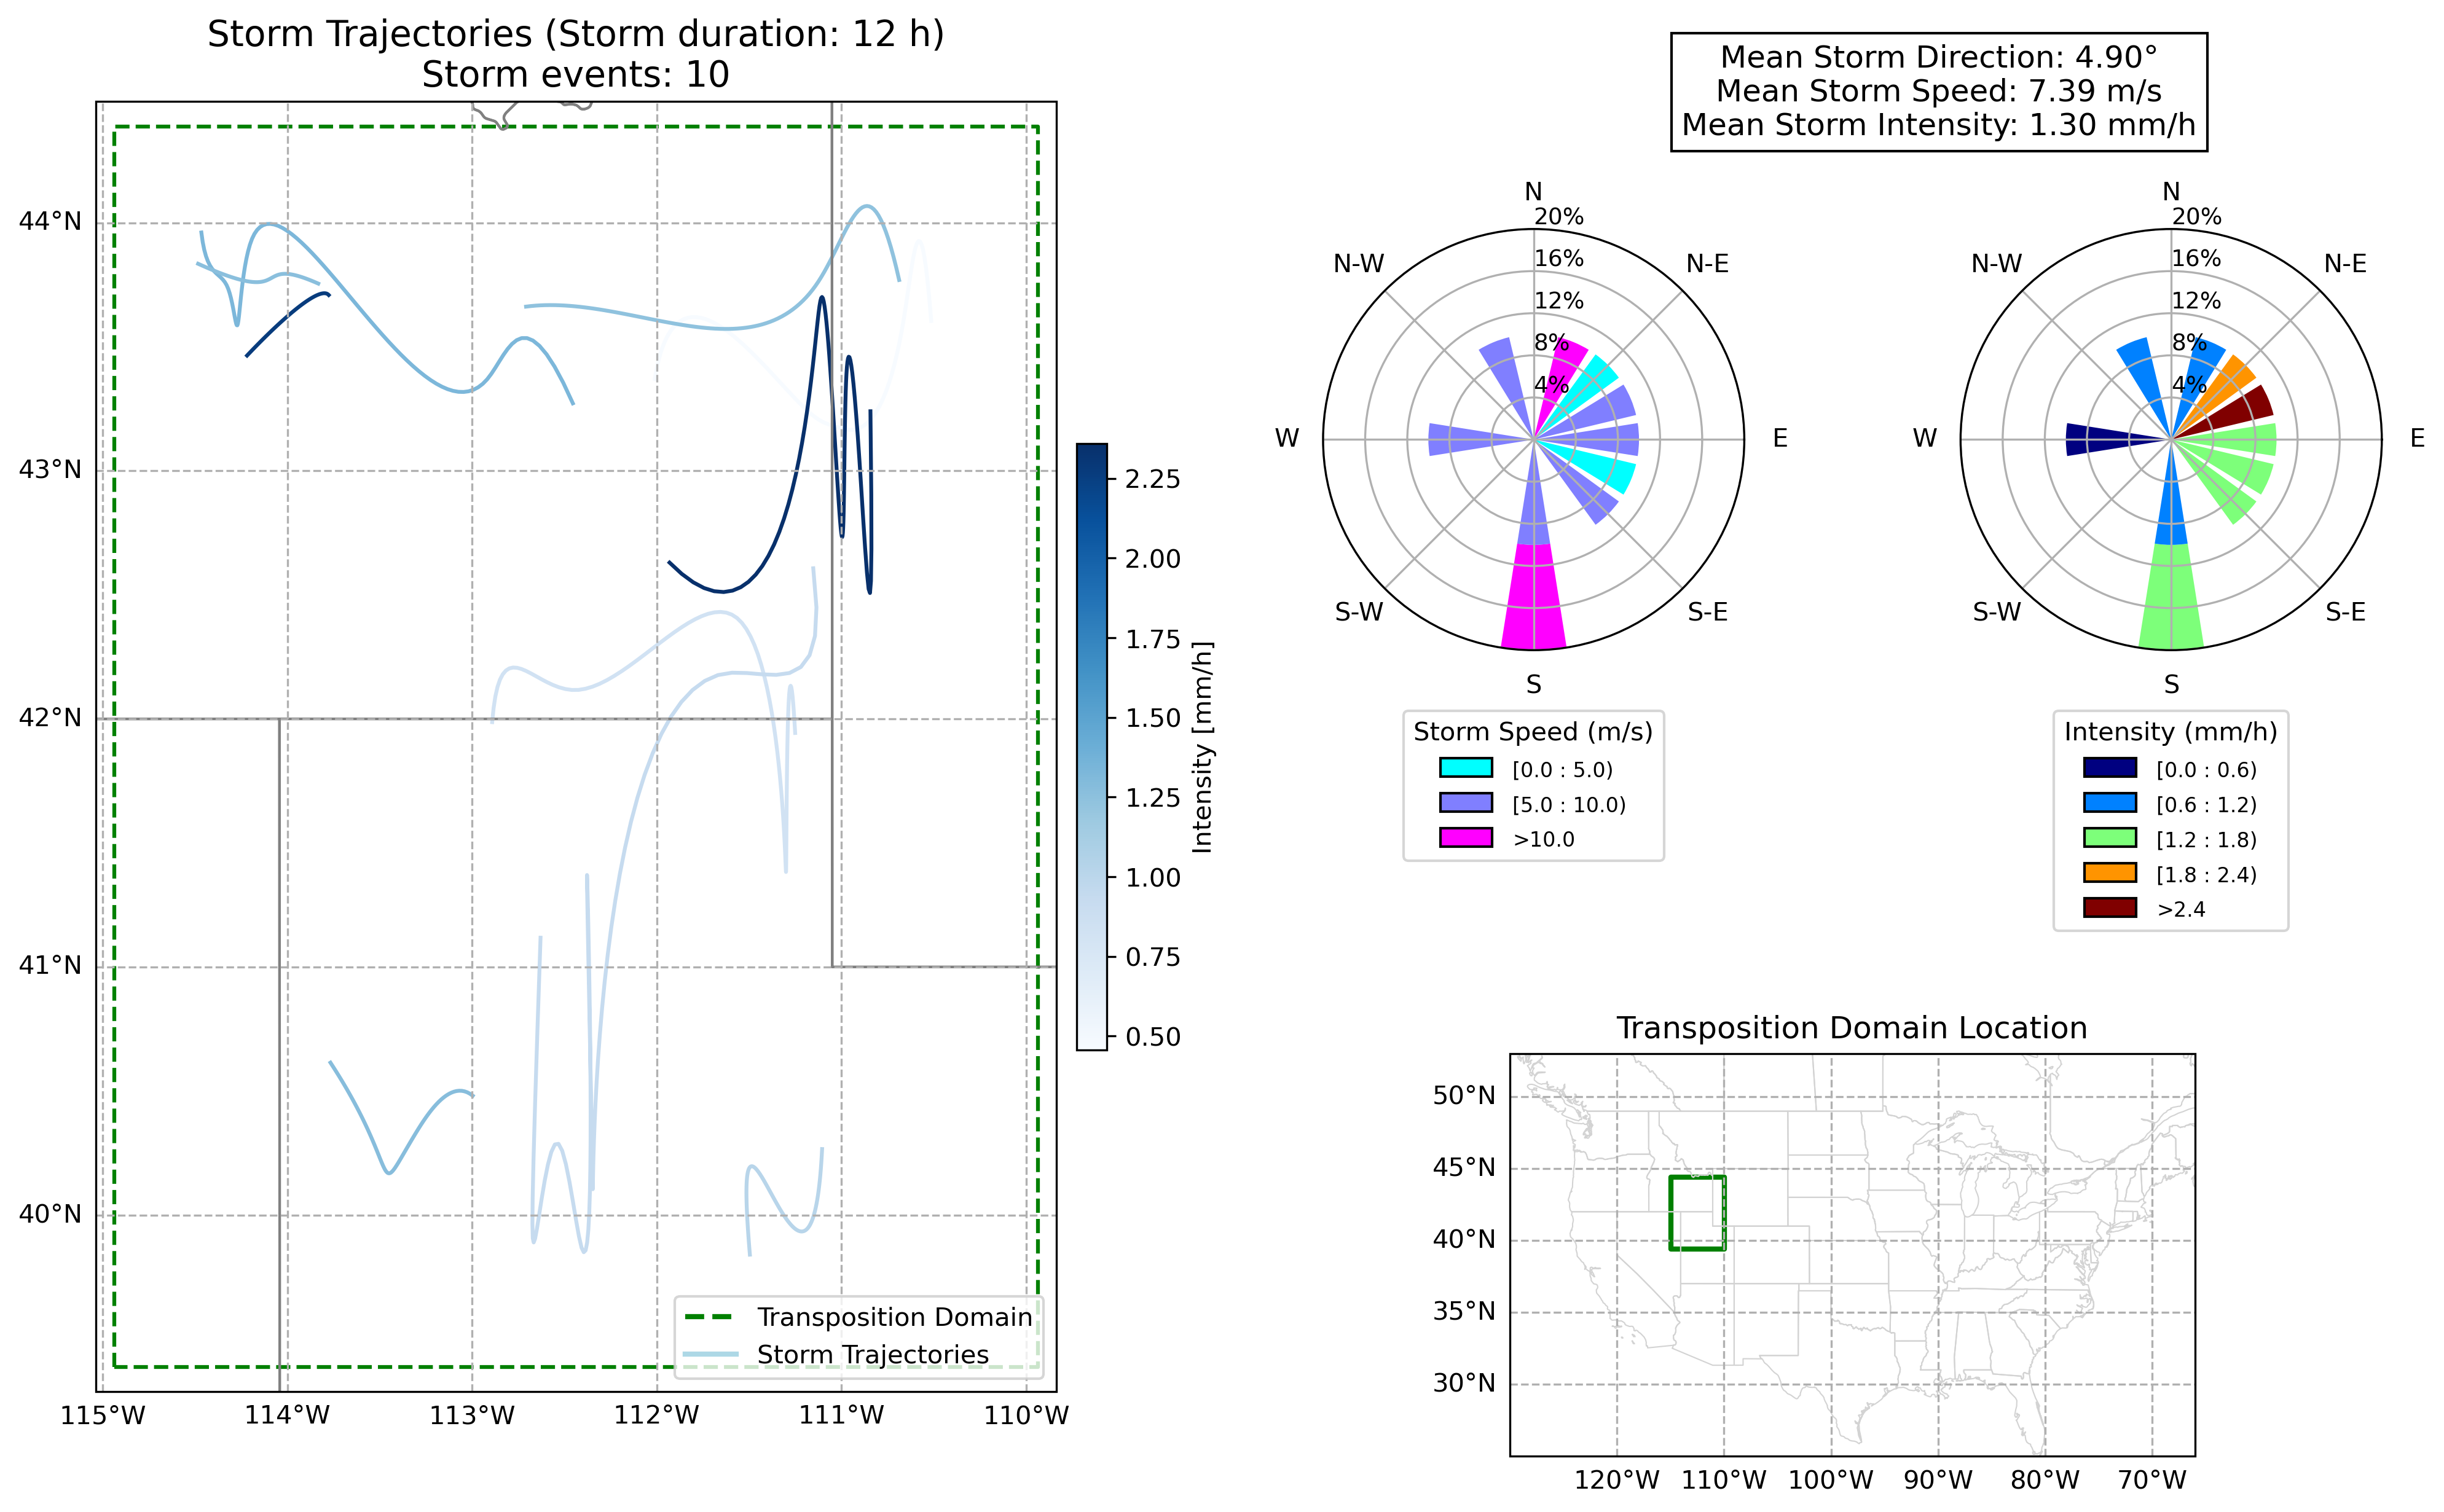

storm_direction_vector_plot_Test Domain.png


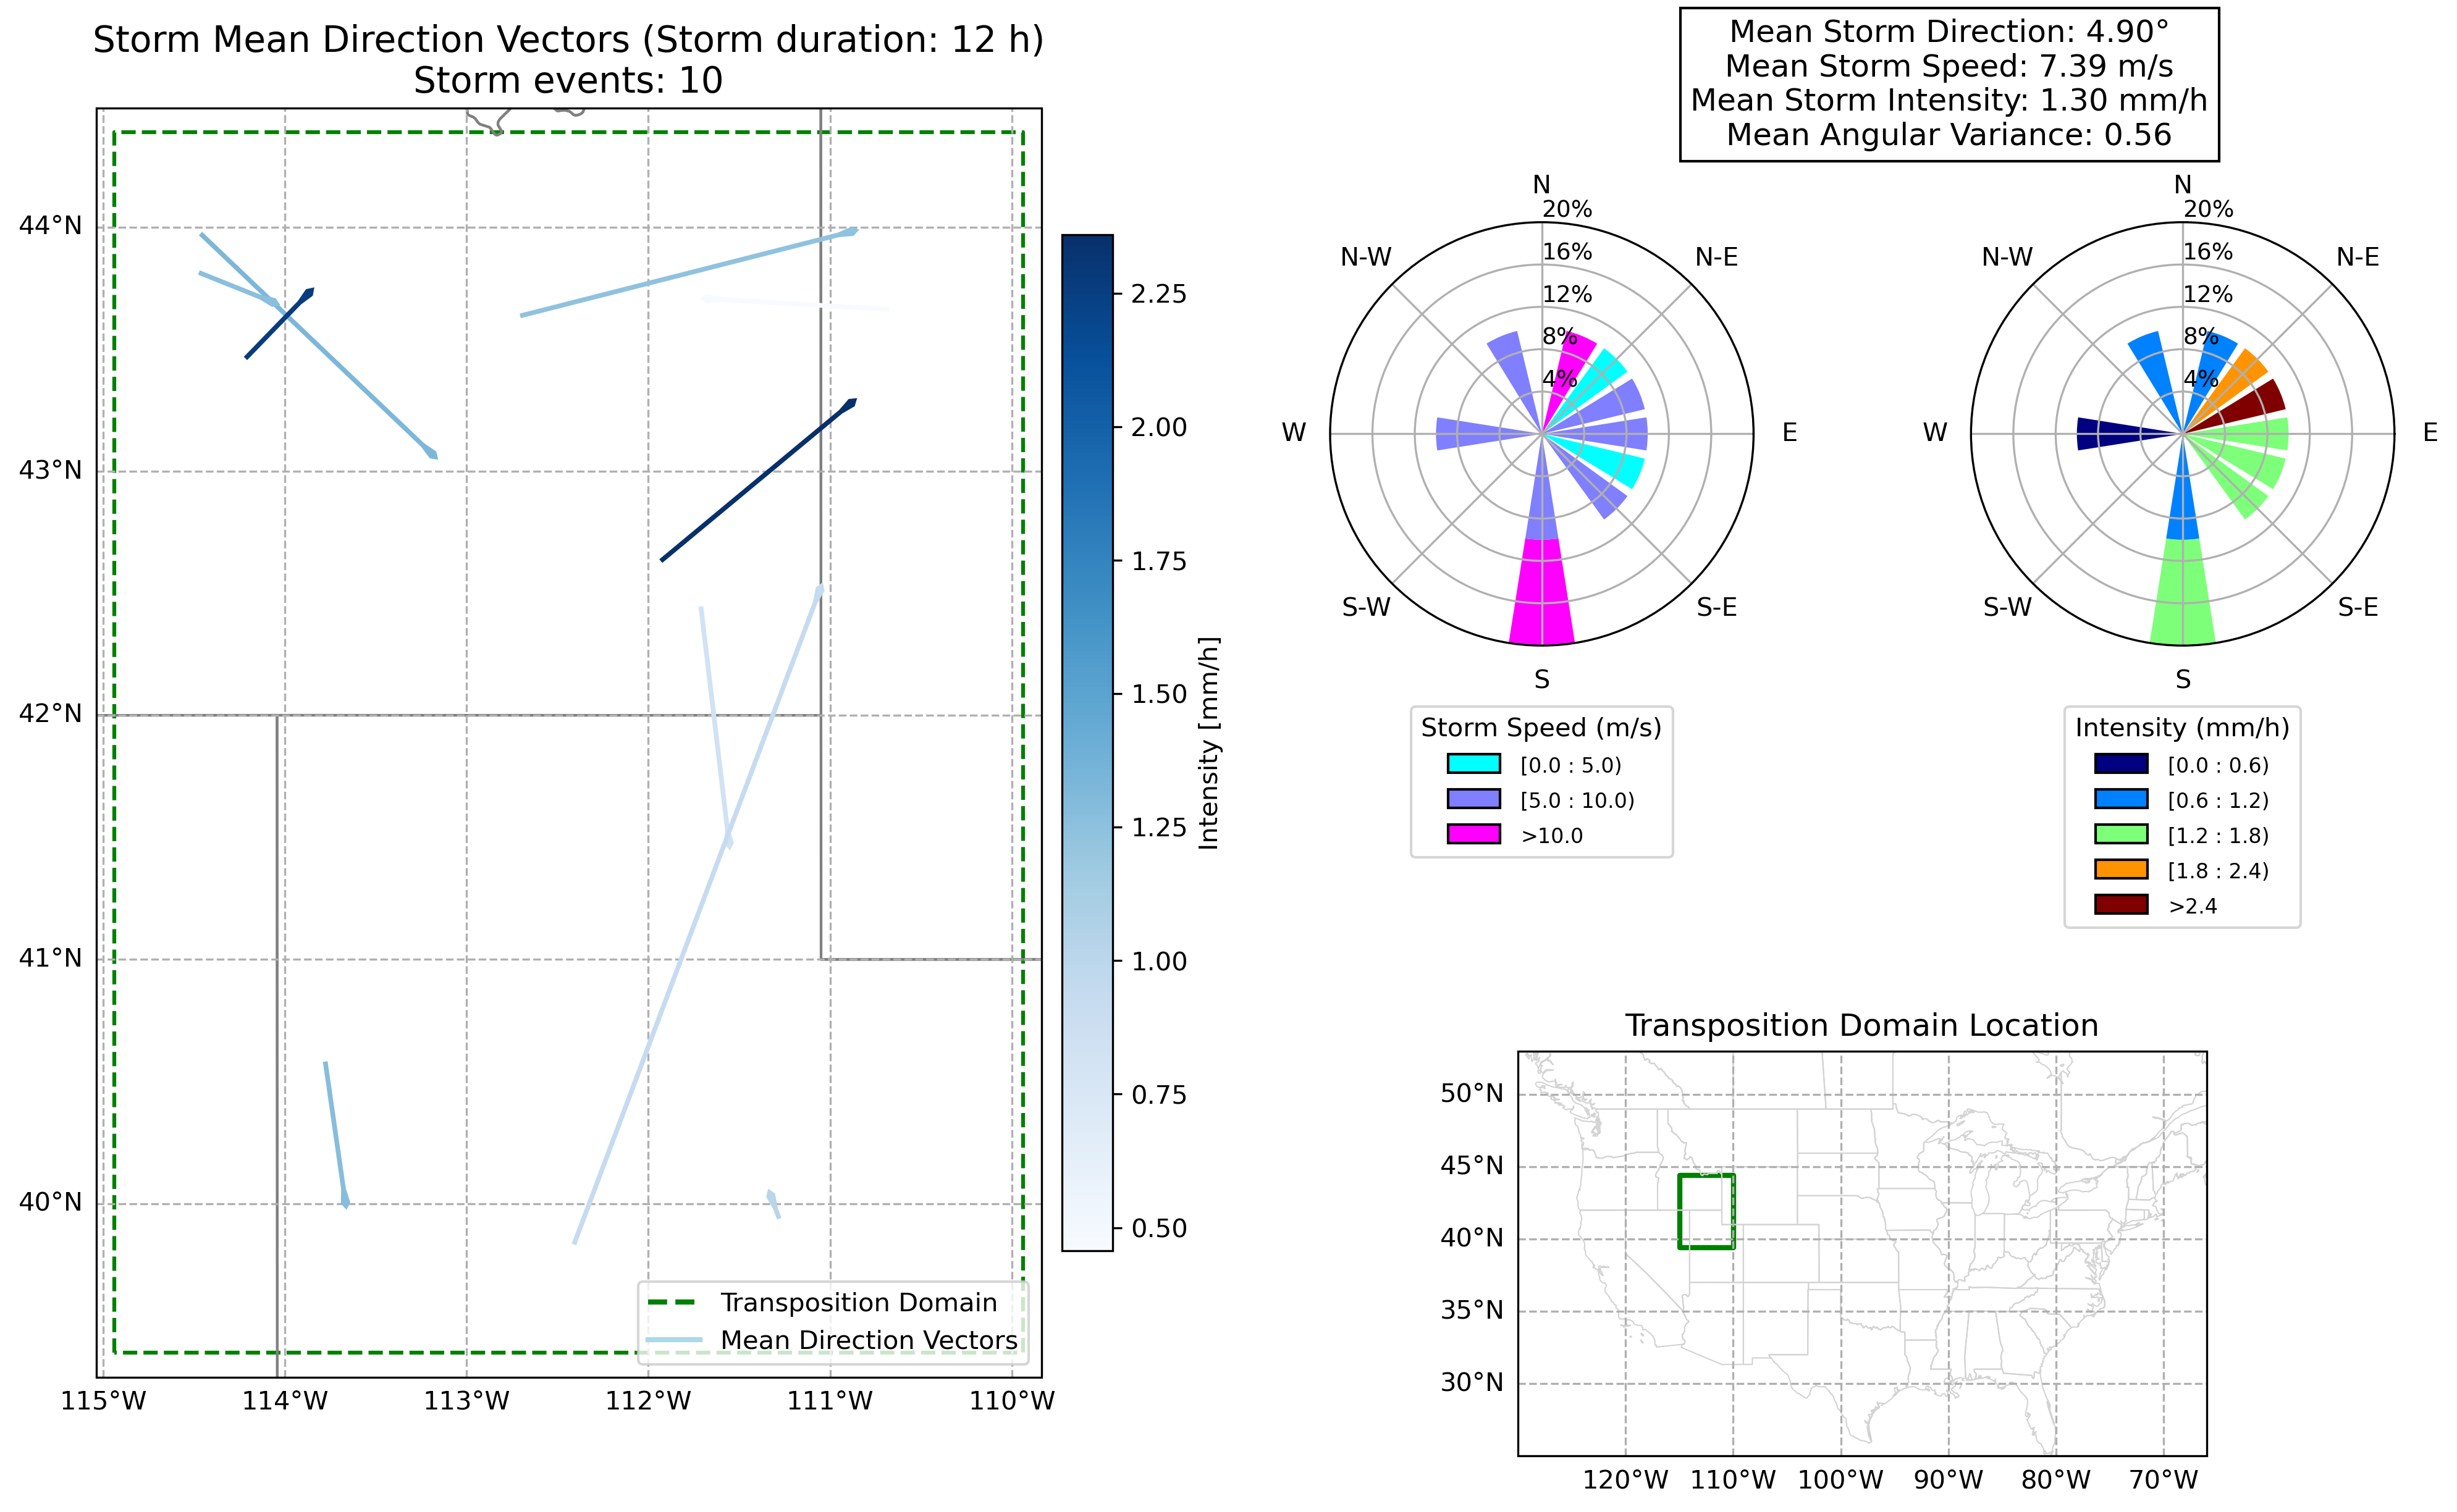

storm_statistics_pairplot_Test Domain.png


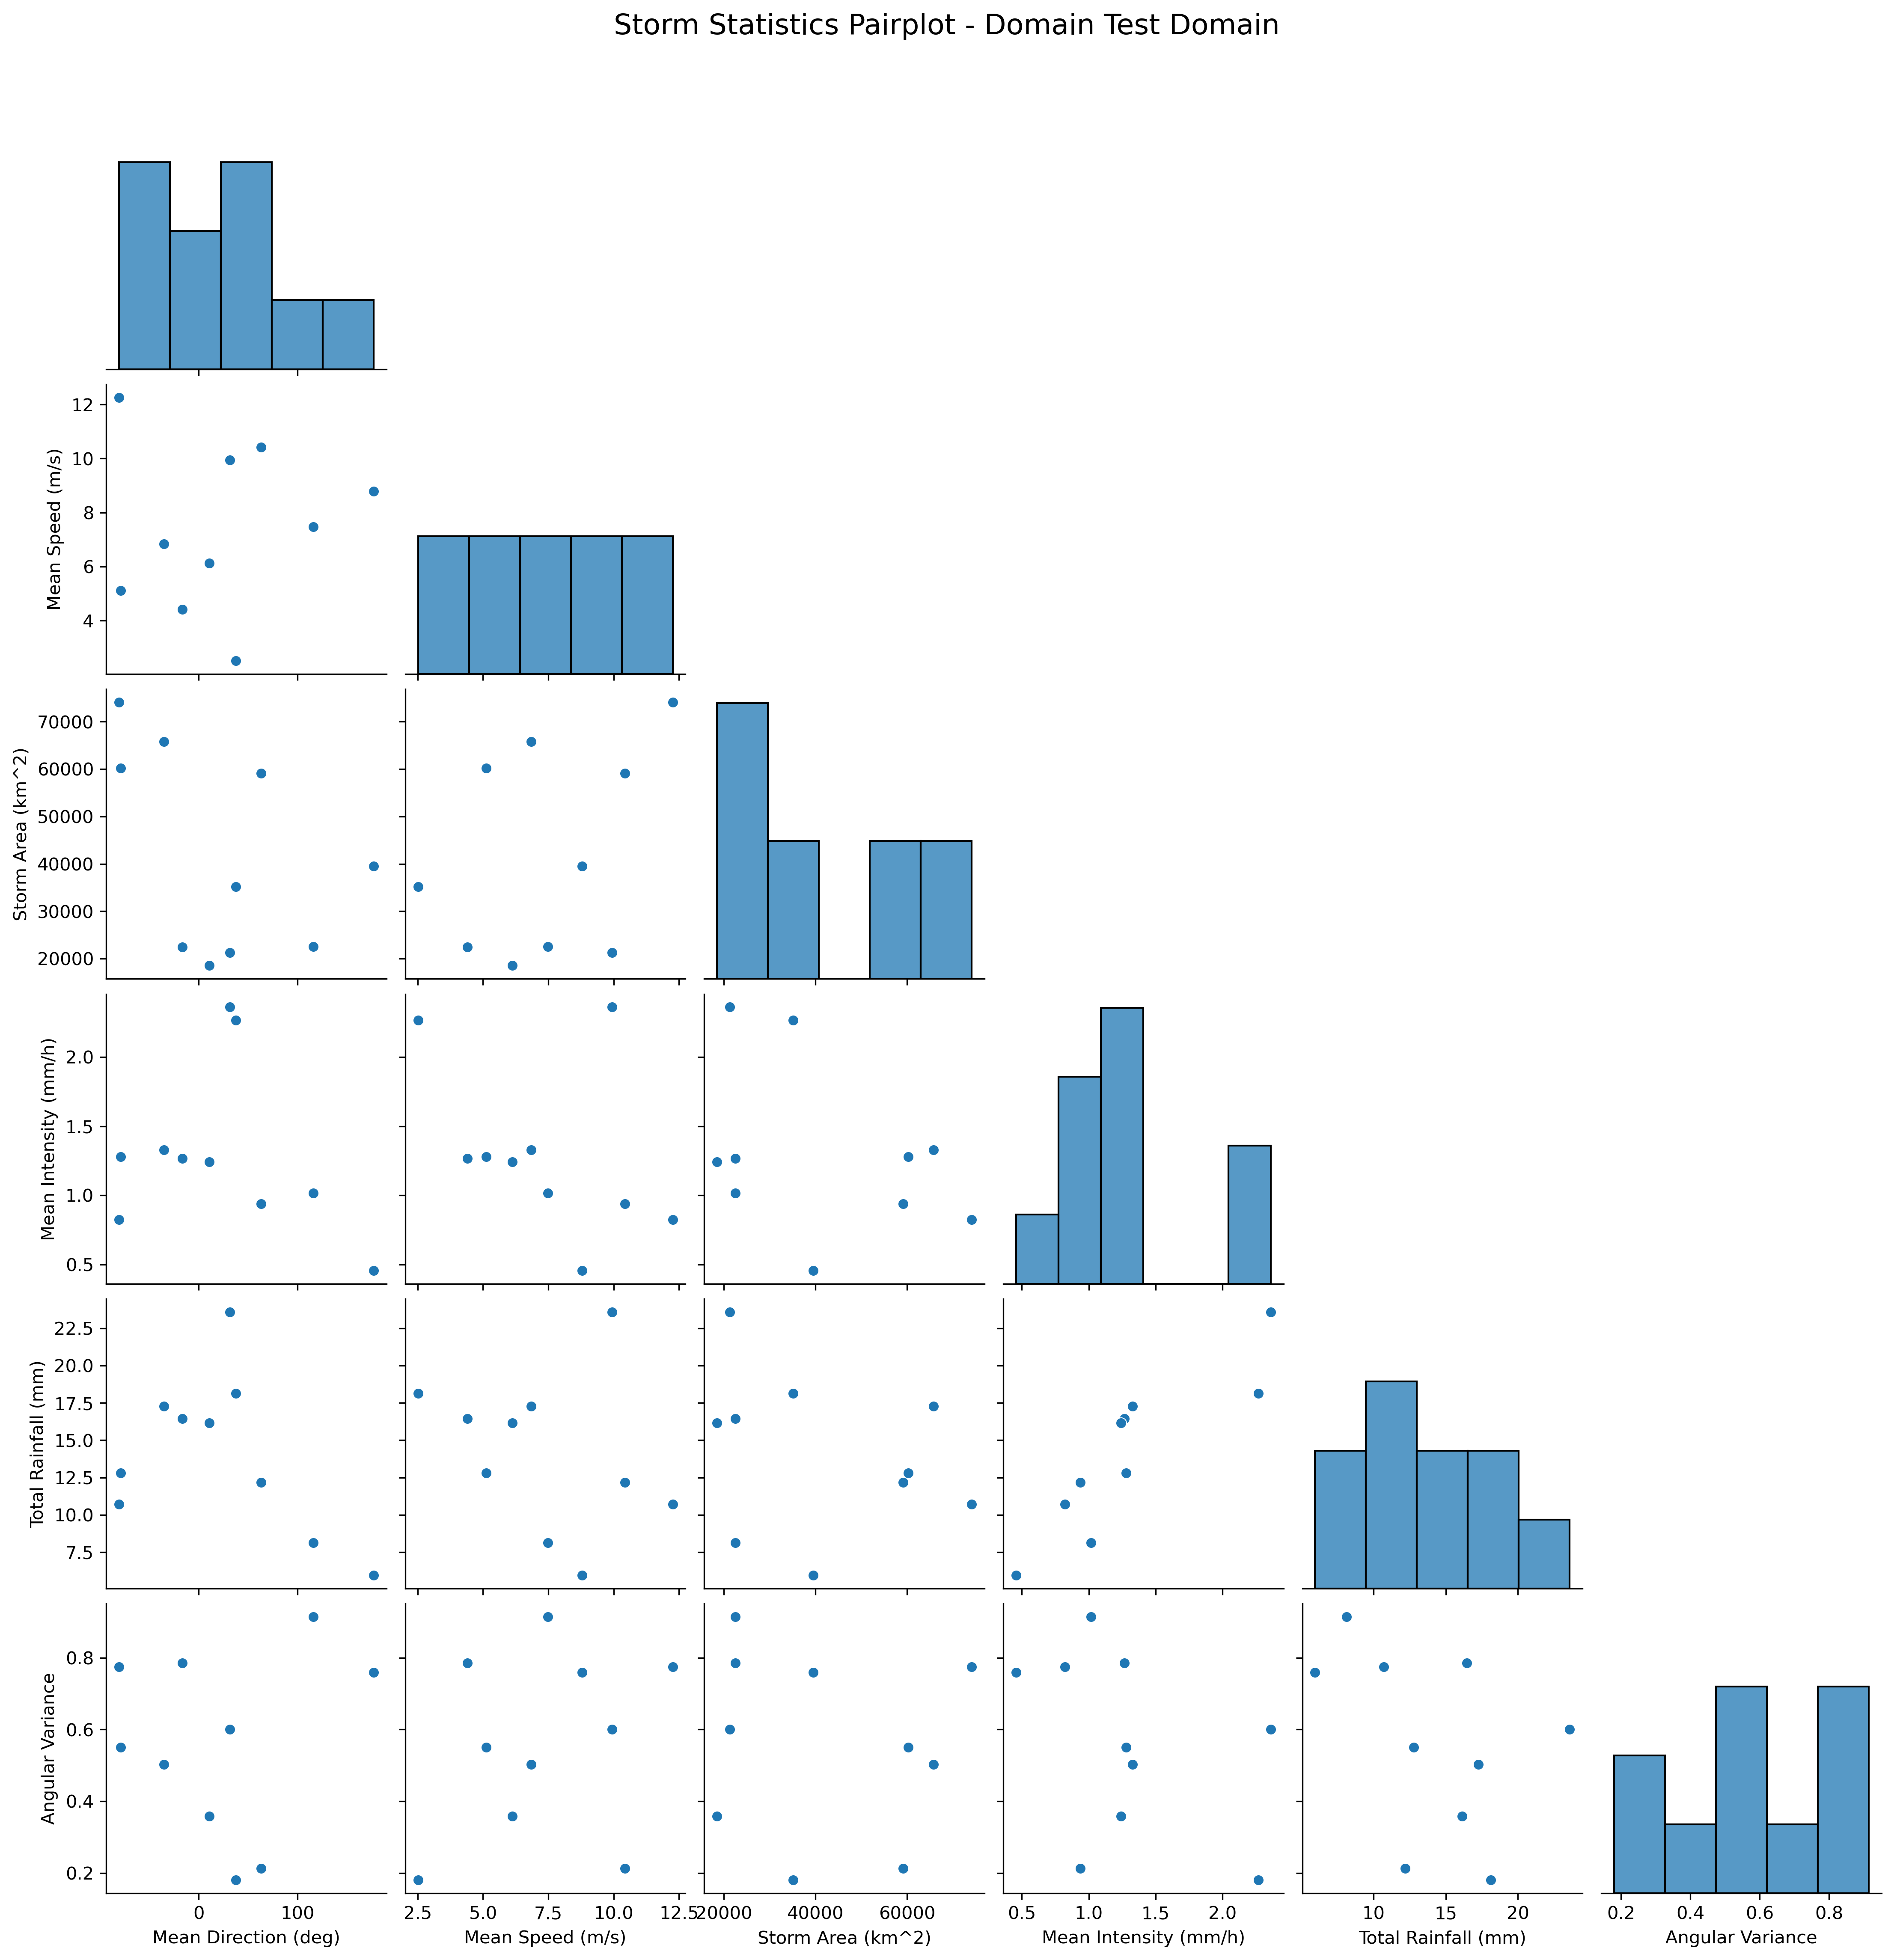

In [10]:
from IPython.display import Image, display
for fig_path in out["figures"]:
    print(fig_path.name)
    display(Image(filename=str(fig_path)))

## 4. Individual per-event figures (all storms)

Generate the storm-track + time-step panels for **every** storm in the catalog
(2 figures per storm). This reuses the tracking results from step 2 (no re-tracking),
but is still slow for large catalogs — subsample with `cfg.io.max_events` if needed.
Figures are saved under `StormTrack/` and `StormTimeSteps/`.


In [11]:
event_figs = pipeline.generate_all_event_diagnostics(cfg, out["results"], summary)
print(f"saved {len(event_figs)} per-event figures")

  per-event figures: 10/10 storms
Saved 20 per-event figures for 10 storms under
  /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/testing_data/Test Domain/StormTrack
  /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/testing_data/Test Domain/StormTimeSteps
saved 20 per-event figures


## 5. Storm-motion direction probability (grid diagnostic)

Build a storm-motion grid per storm, aggregate them into a per-cell **direction-
probability field** (four quadrants I–IV), and render the 4-panel summary:
(a) total directional counts, (b) transposition-domain location, (c) direction-
probability fields, (d) direction regions. Panel (b)'s grid index labels require the
CONUS reference grid (`cfg.io.grid_path`); they are skipped when it is not set.

Uses every retained storm — subsample with `cfg.io.max_events` for a quick look.


Built 10 storm-motion grids (20 km cells); 4 sectors (90 deg each).


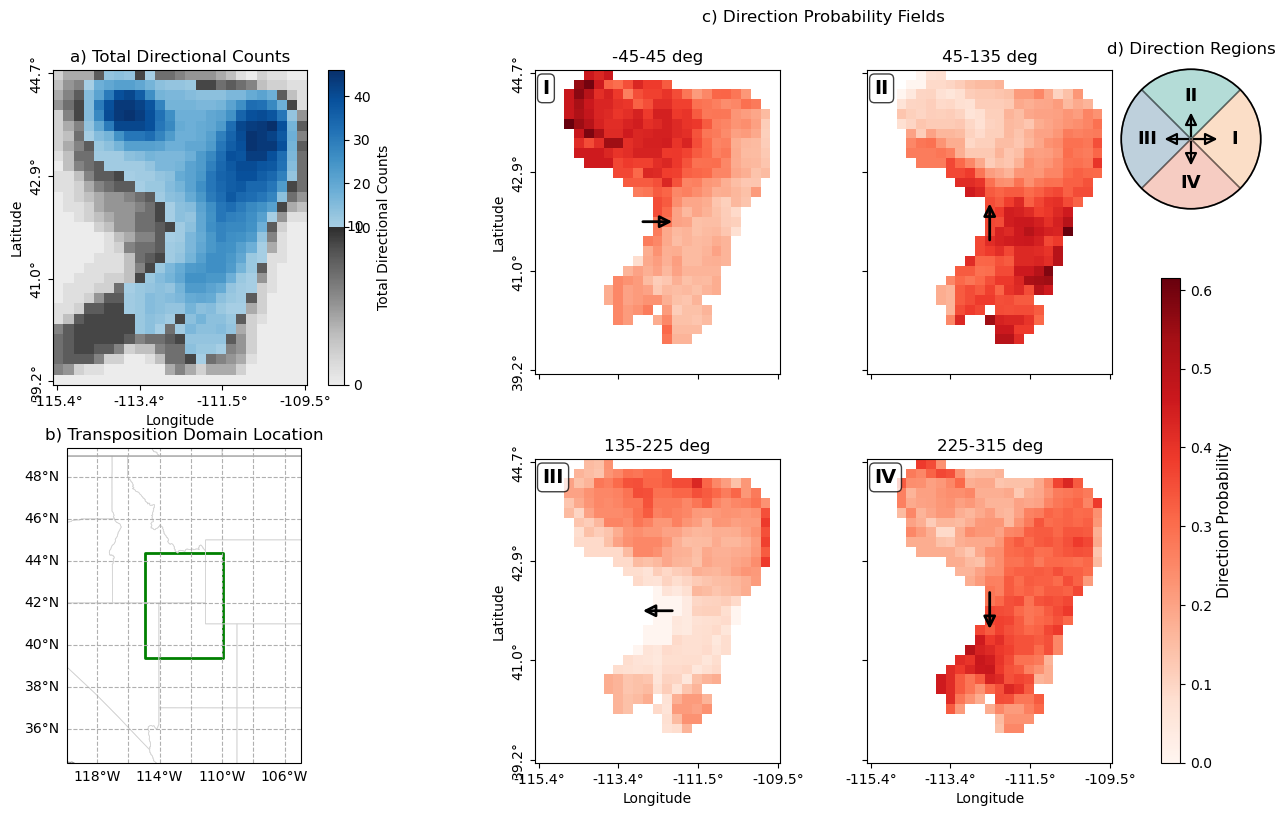

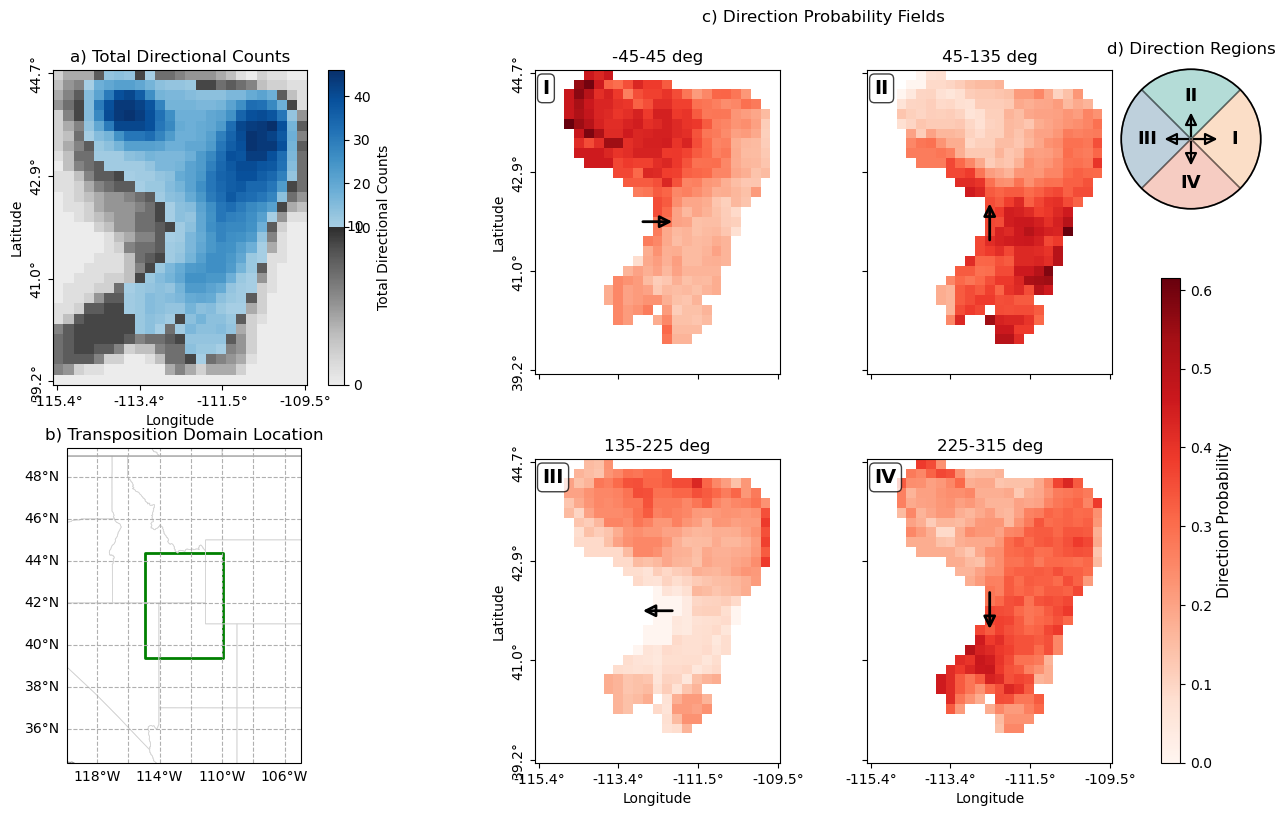

In [14]:
from stormcatalog_analyzer.plotting.motion_grid import plot_direction_probability_summary
from stormcatalog_analyzer import io as scio

# Number of sectors, grid resolution, etc. come from cfg.direction_grid
# (edit configs/testing_data.json -> "direction_grid": {"n_sectors": 8, ...})
cfg.direction_grid.n_sectors = 4
cfg.direction_grid.cell_size_km = 20
cfg.direction_grid.start_angle_deg = -45
cfg.direction_grid.count_threshold = 10
  # limit number of events to process (for testing)
prob_field = pipeline.build_direction_probability_field(out["results"], cfg)
transposition_domain = scio.load_vector(cfg.transposition_domain_path)
grid = scio.load_vector(cfg.grid_path)   # CONUS 5x5 reference grid (optional)

plot_direction_probability_summary(
    prob_field, transposition_domain, grid,
    count_threshold=cfg.direction_grid.count_threshold,
)

## 6. Storm-tracking animation (GIF)

Illustrate the tracking workflow for a single storm as an animated GIF:

1. the **storm moving** (rainfall field stepping through the tracked window),
2. **tracking** — at each step the current fitted **ellipse** and **centroid**, while the
   centroid **trail** and trajectory line accumulate behind it,
3. the full **trajectory** with a **mean-direction vector** spanning the track length and a
   **statistics box** (direction, speed, rainfall intensity, angular variance).

Reuses the tracking results from step 2 (no re-tracking); the GIF is saved under
`StormAnimation/`. Headless, the same is available via
`pipeline.generate_event_animation(cfg, "<storm id/substring>")`.

In [13]:
from stormcatalog_analyzer.plotting.animation import animate_storm_tracking
from stormcatalog_analyzer import io as scio
from IPython.display import Image, display

# Illustrate the tracking workflow for ONE storm as an animated GIF:
#   1) storm (rainfall) moving, 2) per-step fitted ellipse + growing centroid trail,
#   3) full trajectory + mean-direction vector + statistics box.
# Reuses the tracking results from step 2 (no re-tracking). Pick any tracked storm:
storm_name = next((k for k in summary.storm_trajectories if "386" in k), None)   # e.g. next(k for k in summary.storm_trajectories if "_storm_112_" in k)

anim_dir = scio.ensure_output_dirs(cfg)["storm_animation"]
gif_path = animate_storm_tracking(
    out["results"], storm_name, summary.storm_trajectories,
    save_path=str(anim_dir), fps=2,   # fps / hold_frames / rainfall_threshold are tunable
)
print("saved:", gif_path)
display(Image(filename=gif_path))

KeyError: None

In [ ]:
storm_name

'IOWA_Domain.nc_storm_400_20101219.nc'

In [ ]:
summary.storm_trajectories.keys()

dict_keys(['IOWA_Domain.nc_storm_100_20100604.nc', 'IOWA_Domain.nc_storm_101_20151116.nc', 'IOWA_Domain.nc_storm_102_20050506.nc', 'IOWA_Domain.nc_storm_103_20221210.nc', 'IOWA_Domain.nc_storm_104_20091020.nc', 'IOWA_Domain.nc_storm_105_20110607.nc', 'IOWA_Domain.nc_storm_106_20191212.nc', 'IOWA_Domain.nc_storm_107_20200423.nc', 'IOWA_Domain.nc_storm_108_20100118.nc', 'IOWA_Domain.nc_storm_109_20170203.nc', 'IOWA_Domain.nc_storm_10_20150523.nc', 'IOWA_Domain.nc_storm_110_20141101.nc', 'IOWA_Domain.nc_storm_111_20170220.nc', 'IOWA_Domain.nc_storm_112_20160611.nc', 'IOWA_Domain.nc_storm_113_20100908.nc', 'IOWA_Domain.nc_storm_114_20070922.nc', 'IOWA_Domain.nc_storm_115_20121118.nc', 'IOWA_Domain.nc_storm_116_20190920.nc', 'IOWA_Domain.nc_storm_117_20211018.nc', 'IOWA_Domain.nc_storm_118_20110307.nc', 'IOWA_Domain.nc_storm_119_20090224.nc', 'IOWA_Domain.nc_storm_11_20190911.nc', 'IOWA_Domain.nc_storm_120_20020501.nc', 'IOWA_Domain.nc_storm_121_20080110.nc', 'IOWA_Domain.nc_storm_122_20100